In [1]:
import os
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Optional

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from sklearn.metrics import accuracy_score, f1_score

In [ ]:
# Please set your Hugging Face token here if you want to use the LLaMA model
hf_token = "hf_ZXjwJyEluwUmKJwgEFsCEnBhSMQVFasda"

LLAMA_MODEL_NAME   = "meta-llama/Llama-3.1-8B-Instruct"   # requires HF token
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

LABEL_MAP = {0: "Entailment", 1: "Neutral", 2: "Contradiction"}
LABEL_MAP_INV = {v.lower(): k for k, v in LABEL_MAP.items()}

In [3]:

def load_mnli(n_train: Optional[int] = None, n_eval: Optional[int] = None):
    """Load MNLI from HuggingFace. Optionally subsample for quick runs."""
    dataset = load_dataset("nyu-mll/glue", "mnli")

    train = dataset["train"]
    val_matched    = dataset["validation_matched"]
    val_mismatched = dataset["validation_mismatched"]

    if n_train:
        train = train.select(range(n_train))
    if n_eval:
        val_matched    = val_matched.select(range(n_eval))
        val_mismatched = val_mismatched.select(range(n_eval))

    print(f"Train: {len(train)} | Val-matched: {len(val_matched)} | Val-mismatched: {len(val_mismatched)}")
    return train, val_matched, val_mismatched

def extract_answer_attention(attentions, step_idx: int = 0, layer_idx: int = -1):
    """
    For Llama: extract the final generated token's attention from the last layer.
    attentions is a tuple-of-tuples: [step][layer](batch, heads, seq, seq)
    """
    step_idx = len(attentions) - 1
    step_attns = attentions[step_idx]         # tuple of layers
    last_layer = step_attns[layer_idx]        # (batch, heads, seq, seq) tensor
    attn_np    = last_layer[0].cpu().numpy()  # (heads, seq, seq)
    last_tok   = attn_np[:, -1, :]            # heads × seq
    
    return last_tok.mean(axis=0)

In [4]:
def gini_coefficient(attention_row: np.ndarray) -> float:
    """Compute Gini coefficient of a 1-D attention distribution."""
    a = np.sort(np.abs(attention_row.flatten()))
    n = len(a)
    if n == 0 or a.sum() == 0:
        return 0.0
    idx = np.arange(1, n + 1)
    return float((2 * (idx * a).sum()) / (n * a.sum()) - (n + 1) / n)

FEW_SHOT_EXAMPLES = [
    {
        "premise":    "At the end of Rue des Francs-Bourgeois is what many consider to be the city's most handsome residential square, the Place des Vosges, with its stone and red brick facades.",
        "hypothesis": "Place des Vosges is constructed entirely of gray marble.",
        "label":      "Contradiction",
    },
    {
        "premise":    "One of our number will carry out your instructions minutely.",
        "hypothesis": "A member of my team will execute your orders with immense precision.",
        "label":      "Entailment",
    },
    {
        "premise":    "Conceptually cream skimming has two basic dimensions - product and geography.",
        "hypothesis": "Product and geography are what make cream skimming work.",
        "label":      "Neutral",
    },
]


def build_zero_shot_prompt(premise: str, hypothesis: str) -> str:
    return (
        "You are a Natural Language Inference classifier.\n"
        "Given a Premise and a Hypothesis, output exactly one word (Entailment, Neutral, or Contradiction) after Answer.\n"
        "Do not explain.\n\n"
        f"Premise: {premise}\n"
        f"Hypothesis: {hypothesis}\n"
        "Answer: "
    )


def build_few_shot_prompt(premise: str, hypothesis: str) -> str:
    header = (
        "You are a Natural Language Inference classifier.\n"
        "Given a Premise and a Hypothesis, output exactly one word: "
        "Entailment, Neutral, or Contradiction.\n\n"
    )
    examples = ""
    for ex in FEW_SHOT_EXAMPLES:
        examples += (
            f"Premise: {ex['premise']}\n"
            f"Hypothesis: {ex['hypothesis']}\n"
            f"Answer: {ex['label']}\n\n"
        )
    query = (
        f"Premise: {premise}\n"
        f"Hypothesis: {hypothesis}\n"
        "Answer:"
    )
    return header + examples + query


def parse_llama_response(text: str) -> int:
    """Extract the NLI label integer from the raw Llama output."""
    text = text.strip().lower().split()[0] if text.strip() else ""
    for keyword, idx in LABEL_MAP_INV.items():
        if keyword in text:
            return idx
        if str(idx) in text:
            return idx
    return -1  # default to Neutral if unparseable

In [5]:
def find_char_span(prompt: str, text: str, start_marker: str, end_marker: str = None):
    start_marker_pos = prompt.rfind(start_marker)
    if start_marker_pos == -1:
        raise ValueError(f"{start_marker} not found")

    start = start_marker_pos + len(start_marker)

    end_marker_pos = prompt.find(end_marker, start)
    if end_marker_pos == -1:
        end = len(prompt)
    else:
        end = end_marker_pos
    region = prompt[start:end]

    # locate exact text inside region
    text_start = region.index(text)
    abs_start = start + text_start
    abs_end = abs_start + len(text)

    return abs_start, abs_end


def get_premise_hypothesis_token_indices(tokenizer, prompt, premise, hypothesis):
    enc = tokenizer(
        prompt,
        return_tensors="pt",
        return_offsets_mapping=True,
        truncation=True,
    )

    offsets = enc["offset_mapping"][0].tolist()
    premise_span = find_char_span(
        prompt,
        premise,
        start_marker="Premise: ",
        end_marker="\nHypothesis:"
    )

    hypothesis_span = find_char_span(
        prompt,
        hypothesis,
        start_marker="Hypothesis: ",
        end_marker="\nAnswer"
    )

    premise_tokens = []
    hypothesis_tokens = []

    for i, (start, end) in enumerate(offsets):
        if start == end:
            continue

        in_premise = not (end <= premise_span[0] or start >= premise_span[1])
        in_hypothesis = not (end <= hypothesis_span[0] or start >= hypothesis_span[1])

        if in_premise:
            premise_tokens.append(i)
        elif in_hypothesis:
            hypothesis_tokens.append(i)

    return premise_tokens, hypothesis_tokens

In [6]:
class LlamaPipeline:
    def __init__(self, model_name: str = LLAMA_MODEL_NAME, hf_token: Optional[str] = None):
        token = hf_token or os.getenv("HF_TOKEN")
        self.tokenizer = AutoTokenizer.from_pretrained(model_name, token=token)
        self.model = AutoModelForCausalLM.from_pretrained(
            model_name,
            dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
            device_map="auto",
            attn_implementation="eager",
            token=token,
        )
        self.model.eval()

    def _generate(self, prompt: str, max_new_tokens: int = 5):
        inputs = self.tokenizer(prompt, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            output = self.model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                output_attentions=True,
                return_dict_in_generate=True,
                pad_token_id=self.tokenizer.eos_token_id
            )
        generated_ids = output.sequences[0][inputs["input_ids"].shape[-1]:]
        text = self.tokenizer.decode(generated_ids, skip_special_tokens=True)
        # Attentions: tuple of (layer, batch, heads, seq, seq) per generated step
        attentions = output.attentions if hasattr(output, "attentions") else None
        return text, attentions, inputs

    def predict_zero_shot(self, premise: str, hypothesis: str):
        prompt = build_zero_shot_prompt(premise, hypothesis)
        text, attentions, inputs = self._generate(prompt)
        label = parse_llama_response(text)
        return label, text, attentions, inputs

    def predict_few_shot(self, premise: str, hypothesis: str):
        prompt = build_few_shot_prompt(premise, hypothesis)
        text, attentions, inputs = self._generate(prompt)
        label = parse_llama_response(text)
        return label, text, attentions, inputs

    def evaluate(self, dataset, mode: str = "zero_shot"):
        assert mode in ("zero_shot", "few_shot")
        all_preds, all_labels = [], []
        premise_scores, hypothesis_scores = [], []
        all_gini = []
        correct_gini = []
        wrong_gini = []
        e_gini, n_gini, g_gini = [], [], []
        P_H_by_label = {
            "entailment": {"premise_gini": [], "hypothesis_gini": [], "premise_percent": [], "hypothesis_percent": []},
            "neutral": {"premise_gini": [], "hypothesis_gini": [], "premise_percent": [], "hypothesis_percent": []},
            "contradiction": {"premise_gini": [], "hypothesis_gini": [], "premise_percent": [], "hypothesis_percent": []},
        }
        for example in dataset:
            premise    = example["premise"]
            hypothesis = example["hypothesis"]
            label      = example["label"]

            if mode == "zero_shot":
                prompt = build_zero_shot_prompt(premise, hypothesis)
            else:
                prompt = build_few_shot_prompt(premise, hypothesis)
            text, attentions, inputs = self._generate(prompt)
            pred = parse_llama_response(text)
            if pred == -1:
                continue

            premise_tokens, hypothesis_tokens = get_premise_hypothesis_token_indices(
                self.tokenizer,
                prompt,
                premise,
                hypothesis
            )

            answer_attn = extract_answer_attention(attentions)
            input_len = inputs["input_ids"].shape[-1]
            answer_attn = answer_attn[:input_len]

            premise_attn = answer_attn[premise_tokens]
            hypothesis_attn = answer_attn[hypothesis_tokens]
            premise_gini = gini_coefficient(premise_attn)
            hypothesis_gini = gini_coefficient(hypothesis_attn)

            premise_score = premise_attn.sum()
            hypothesis_score = hypothesis_attn.sum()
            total = premise_score + hypothesis_score
            if total > 0:
                premise_score = premise_score / total
                hypothesis_score = hypothesis_score / total
            label_name = LABEL_MAP[label].lower()

            P_H_by_label[label_name]["premise_gini"].append(premise_gini)
            P_H_by_label[label_name]["hypothesis_gini"].append(hypothesis_gini)

            P_H_by_label[label_name]["premise_percent"].append(premise_score * 100)
            P_H_by_label[label_name]["hypothesis_percent"].append(hypothesis_score * 100)


            gini = gini_coefficient(answer_attn)
            all_gini.append(gini)
            if pred == label:
                correct_gini.append(gini)
            else:
                wrong_gini.append(gini)
            if label == 0:
                e_gini.append(gini)
            elif label == 1:
                n_gini.append(gini)
            else:
                g_gini.append(gini)

            all_preds.append(pred)
            all_labels.append(label)

            
        all_gini_dict  = {
            "all": all_gini,
            "correct": correct_gini,
            "wrong": wrong_gini,
            "entailment": e_gini,
            "neutral": n_gini,
            "contradiction": g_gini,
        }
        acc = accuracy_score(all_labels, all_preds)
        f1  = f1_score(all_labels, all_preds, average="macro")
        
        return acc, f1, P_H_by_label, all_gini_dict 

In [7]:
llama = LlamaPipeline(hf_token=hf_token)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


In [8]:
train, val_matched, val_mismatched = load_mnli(n_eval=1000)

Train: 392702 | Val-matched: 1000 | Val-mismatched: 1000


In [9]:
zs_acc, zs_f1, zs_P_H_by_label, zs_gini_dict = llama.evaluate(val_matched, mode="zero_shot")
print(f"  Matched: Accuracy={zs_acc:.4f}  F1={zs_f1:.4f}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  Matched: Accuracy=0.5559  F1=0.5615


In [10]:
print("\n===== PERFORMANCE =====")
print(f"Accuracy: {zs_acc:.4f}")
print(f"Macro F1: {zs_f1:.4f}")
all_premise = []
all_hypothesis = []
for label in zs_P_H_by_label:
    p = zs_P_H_by_label[label]["premise_percent"]
    h = zs_P_H_by_label[label]["hypothesis_percent"]
    all_premise.extend(p)
    all_hypothesis.extend(h)
    if len(p) == 0:
        print(f"{label:15s}: EMPTY")
        continue

    print(f"\n[{label.upper()}]")
    print(f"  Premise:    mean={np.mean(p):.4f}, n={len(p)}")
    print(f"  Hypothesis: mean={np.mean(h):.4f}, n={len(h)}")
print(f"\nPremise (all):    mean={np.mean(all_premise):.4f}, n={len(all_premise)}")
print(f"Hypothesis (all): mean={np.mean(all_hypothesis):.4f}, n={len(all_hypothesis)}")
    # Gini
print("\n===== GINI =====")
for key, values in zs_gini_dict.items():
    if len(values) == 0:
        print(f"{key:20s}: EMPTY")
    else:
        print(f"{key:20s}: mean={np.mean(values):.4f}, std={np.std(values):.4f}, n={len(values)}")

print("\n================================================\n")


===== PERFORMANCE =====
Accuracy: 0.5559
Macro F1: 0.5615

[ENTAILMENT]
  Premise:    mean=42.9481, n=269
  Hypothesis: mean=57.0538, n=269

[NEUTRAL]
  Premise:    mean=39.4840, n=205
  Hypothesis: mean=60.5141, n=205

[CONTRADICTION]
  Premise:    mean=34.9752, n=224
  Hypothesis: mean=65.0273, n=224

Premise (all):    mean=39.3721, n=698
Hypothesis (all): mean=60.6289, n=698

===== GINI =====
all                 : mean=0.9225, std=0.0353, n=698
correct             : mean=0.9319, std=0.0283, n=388
wrong               : mean=0.9108, std=0.0395, n=310
entailment          : mean=0.9100, std=0.0415, n=269
neutral             : mean=0.9211, std=0.0339, n=205
contradiction       : mean=0.9388, std=0.0179, n=224




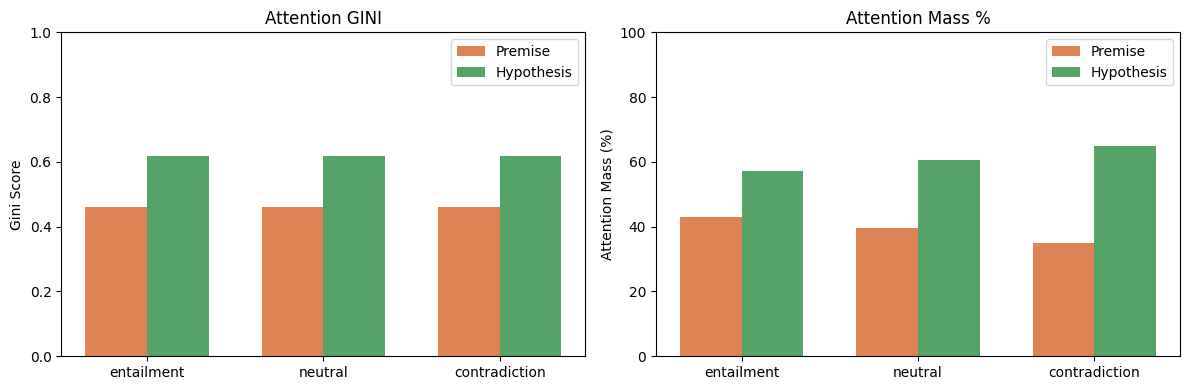

In [11]:
labels = ["entailment", "neutral", "contradiction"]
x = np.arange(len(labels))
width = 0.35

premise_ginis = [np.mean(zs_P_H_by_label[label]["premise_gini"]) for label in labels]
hypothesis_ginis = [np.mean(zs_P_H_by_label[label]["hypothesis_gini"]) for label in labels]

premise_percents = [np.mean(zs_P_H_by_label[label]["premise_percent"]) for label in labels]
hypothesis_percents = [np.mean(zs_P_H_by_label[label]["hypothesis_percent"]) for label in labels]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(x - width/2, np.mean(premise_ginis), width, label="Premise", color="#DD8452")
axes[0].bar(x + width/2, np.mean(hypothesis_ginis), width, label="Hypothesis", color="#55A467")
axes[0].set_title("Attention GINI")
axes[0].set_ylabel("Gini Score")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylim(0, 1)
axes[0].legend()

axes[1].bar(x - width/2, premise_percents, width, label="Premise", color="#DD8452")
axes[1].bar(x + width/2, hypothesis_percents, width, label="Hypothesis", color="#55A467")
axes[1].set_title("Attention Mass %")
axes[1].set_ylabel("Attention Mass (%)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylim(0, 100)
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
torch.cuda.empty_cache()

In [13]:
fs_acc, fs_f1, fs_P_H_by_label, fs_gini_dict = llama.evaluate(val_matched, mode="few_shot")
print(f"  Matched: Accuracy={fs_acc:.4f}  F1={fs_f1:.4f}")

  Matched: Accuracy=0.7420  F1=0.7217


In [14]:
print("\n===== PERFORMANCE =====")
print(f"Accuracy: {fs_acc:.4f}")
print(f"Macro F1: {fs_f1:.4f}")
all_premise = []
all_hypothesis = []
for label in fs_P_H_by_label:
    p = fs_P_H_by_label[label]["premise_percent"]
    h = fs_P_H_by_label[label]["hypothesis_percent"]
    all_premise.extend(p)
    all_hypothesis.extend(h)
    if len(p) == 0:
        print(f"{label:15s}: EMPTY")
        continue

    print(f"\n[{label.upper()}]")
    print(f"  Premise:    mean={np.mean(p):.4f}, n={len(p)}")
    print(f"  Hypothesis: mean={np.mean(h):.4f}, n={len(h)}")
print(f"\nPremise (all):    mean={np.mean(all_premise):.4f}, n={len(all_premise)}")
print(f"Hypothesis (all): mean={np.mean(all_hypothesis):.4f}, n={len(all_hypothesis)}")
    # Gini
print("\n===== GINI =====")
for key, values in fs_gini_dict.items():
    if len(values) == 0:
        print(f"{key:20s}: EMPTY")
    else:
        print(f"{key:20s}: mean={np.mean(values):.4f}, std={np.std(values):.4f}, n={len(values)}")

print("\n================================================\n")


===== PERFORMANCE =====
Accuracy: 0.7420
Macro F1: 0.7217

[ENTAILMENT]
  Premise:    mean=53.7496, n=341
  Hypothesis: mean=46.2475, n=341

[NEUTRAL]
  Premise:    mean=57.6849, n=319
  Hypothesis: mean=42.3151, n=319

[CONTRADICTION]
  Premise:    mean=53.6595, n=340
  Hypothesis: mean=46.3409, n=340

Premise (all):    mean=54.9743, n=1000
Hypothesis (all): mean=45.0248, n=1000

===== GINI =====
all                 : mean=0.9224, std=0.0261, n=1000
correct             : mean=0.9225, std=0.0261, n=742
wrong               : mean=0.9220, std=0.0262, n=258
entailment          : mean=0.9321, std=0.0142, n=341
neutral             : mean=0.9064, std=0.0334, n=319
contradiction       : mean=0.9276, std=0.0199, n=340




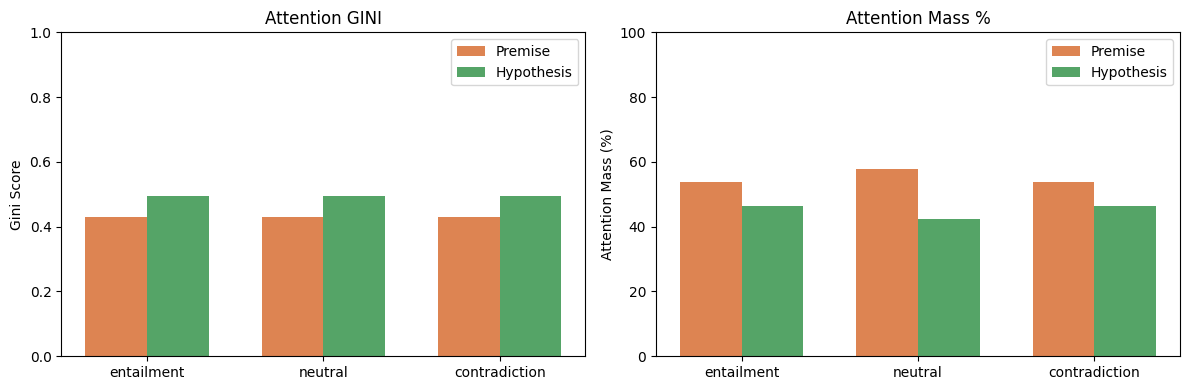

In [15]:
labels = ["entailment", "neutral", "contradiction"]
x = np.arange(len(labels))
width = 0.35

premise_ginis = [np.mean(fs_P_H_by_label[label]["premise_gini"]) for label in labels]
hypothesis_ginis = [np.mean(fs_P_H_by_label[label]["hypothesis_gini"]) for label in labels]

premise_percents = [np.mean(fs_P_H_by_label[label]["premise_percent"]) for label in labels]
hypothesis_percents = [np.mean(fs_P_H_by_label[label]["hypothesis_percent"]) for label in labels]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(x - width/2, np.mean(premise_ginis), width, label="Premise", color="#DD8452")
axes[0].bar(x + width/2, np.mean(hypothesis_ginis), width, label="Hypothesis", color="#55A467")
axes[0].set_title("Attention GINI")
axes[0].set_ylabel("Gini Score")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylim(0, 1)
axes[0].legend()

axes[1].bar(x - width/2, premise_percents, width, label="Premise", color="#DD8452")
axes[1].bar(x + width/2, hypothesis_percents, width, label="Hypothesis", color="#55A467")
axes[1].set_title("Attention Mass %")
axes[1].set_ylabel("Attention Mass (%)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylim(0, 100)
axes[1].legend()

plt.tight_layout()
plt.show()

In [16]:
def compare_attention_heatmaps(
    tokens_zs: list, attn_zs: np.ndarray,
    tokens_fs: list, attn_fs: np.ndarray,
    save_path: Optional[str] = None,
):
    """Side-by-side zero-shot vs few-shot attention for Llama."""
    fig, axes = plt.subplots(1, 2, figsize=(18, 4))
    for ax, tokens, attention, title in zip(
        axes,
        [tokens_zs, tokens_fs],
        [attn_zs,   attn_fs],
        ["Llama Zero-Shot Attention", "Llama 3-Shot Attention"],
    ):
        n = min(len(tokens), len(attention))
        gini = gini_coefficient(attention)
        
        tokens, attention = tokens[:n], attention[:n]
        sns.barplot(x=list(range(n)), y=attention, ax=ax, color="coral")
        ax.set_xticks(range(n))
        ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=8)
        ax.set_ylabel("Attention Weight")
        
        ax.set_title(f"{title}  |  Gini={gini:.4f}")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"Saved: {save_path}")
    plt.show()


Llama Zero-Shot Gini: 0.8679
Llama Few-Shot  Gini: 0.8902
Saved: llama_attention_comparison.png


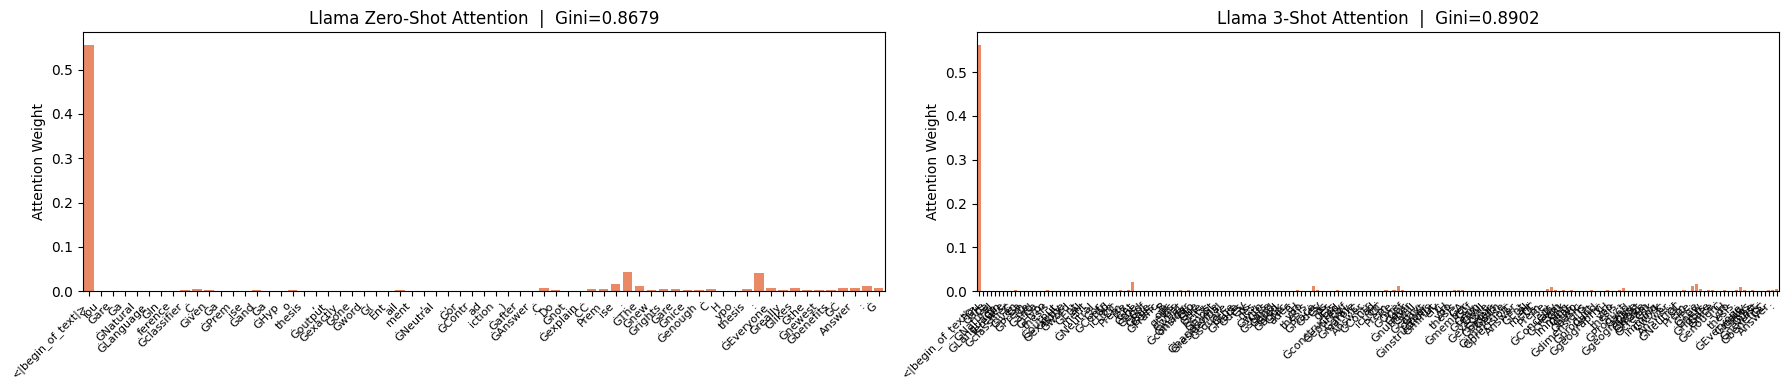

In [17]:
# 1. Get the last layer's attention
sample = val_matched[0]
p, h = sample["premise"], sample["hypothesis"]
_, _, zs_attentions, zs_inputs = llama.predict_zero_shot(p, h)
_, _, fs_attentions, fs_inputs = llama.predict_few_shot(p, h)

zs_tokens = llama.tokenizer.convert_ids_to_tokens(zs_inputs["input_ids"][0])
fs_tokens = llama.tokenizer.convert_ids_to_tokens(fs_inputs["input_ids"][0])

if zs_attentions and fs_attentions:
    zs_attn = extract_answer_attention(zs_attentions)
    fs_attn = extract_answer_attention(fs_attentions)

    print(f"\nLlama Zero-Shot Gini: {gini_coefficient(zs_attn):.4f}")
    print(f"Llama Few-Shot  Gini: {gini_coefficient(fs_attn):.4f}")

    compare_attention_heatmaps(
        zs_tokens, zs_attn,
        fs_tokens, fs_attn,
        save_path="llama_attention_comparison.png",
    )


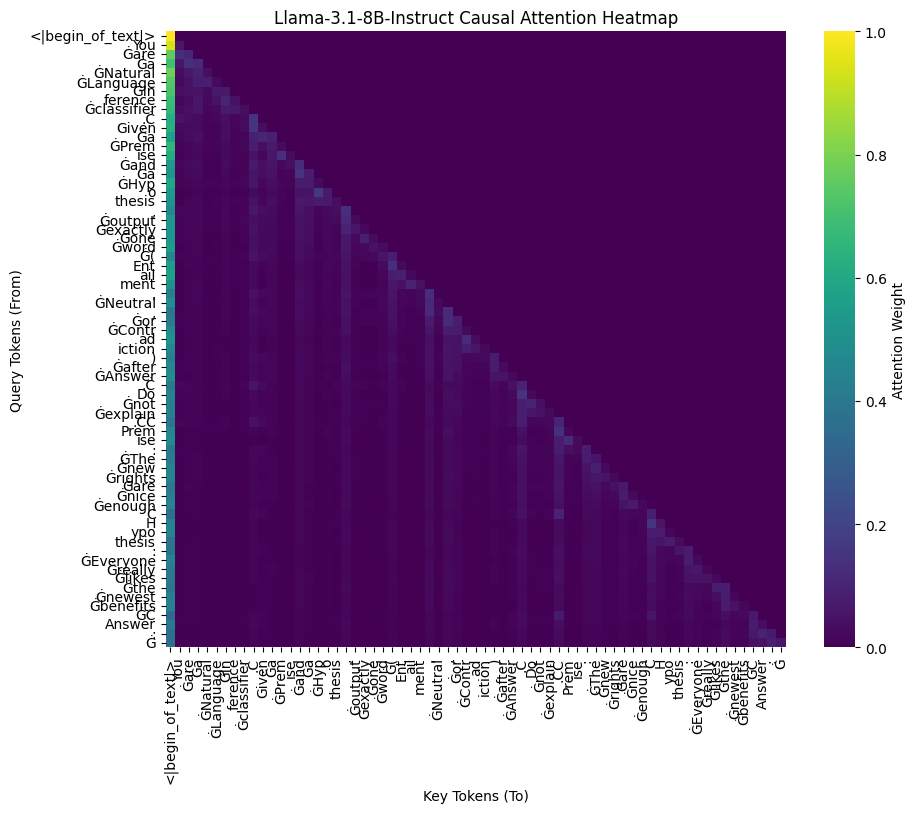

In [18]:
# 1. Get the last layer's attention [cite: 164]
last_layer_attn = zs_attentions[0][0].squeeze(0) # Shape: (heads, seq_len, seq_len)

# 2. Average across heads (or select a specific head)
avg_attn = last_layer_attn.mean(dim=0).detach().cpu().numpy()

# 3. Create the heatmap
plt.figure(figsize=(10, 8))
zs_tokens = llama.tokenizer.convert_ids_to_tokens(zs_inputs["input_ids"][0])

sns.heatmap(
    avg_attn, 
    xticklabels=zs_tokens, 
    yticklabels=zs_tokens, 
    cmap="viridis",
    cbar_kws={'label': 'Attention Weight'}
)

plt.title("Llama-3.1-8B-Instruct Causal Attention Heatmap")
plt.xlabel("Key Tokens (To)")
plt.ylabel("Query Tokens (From)")
plt.show()